# 02 – Technician Dispatch Optimization
## Business Context
A ServiceTitan contractor has 10 technicians and receives 40-80 service calls daily across a metro area.
Dispatchers must assign and sequence jobs in real time while dealing with:
- New calls arriving throughout the day
- Jobs running over/under estimated duration
- Traffic and travel time
- Technician skill requirements (not every tech does every job type)
- Customer time window preferences (morning vs. afternoon)

Poor dispatch = overtime, unhappy customers, wasted drive time.

## ML's Role
Pure optimization handles the assignment (Greedy/OR-Tools). ML provides **learned inputs**:
- Job duration prediction (most impactful)
- Travel time modeling (time-of-day aware)
- First-time fix probability

This notebook focuses on the **job duration prediction model** — the single most impactful
ML component in the dispatch stack.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Synthetic Job History Dataset ───────────────────────────────────────────
# Each row is a completed job with known ground-truth duration

N = 8000  # historical jobs

job_types = ['ac_repair', 'ac_install', 'furnace_repair', 'furnace_install',
             'drain_clear', 'water_heater', 'electrical_panel', 'tune_up']

# Base durations (minutes) per job type — realistic HVAC/plumbing ranges
base_duration = {
    'ac_repair': 90, 'ac_install': 240, 'furnace_repair': 75,
    'furnace_install': 210, 'drain_clear': 45, 'water_heater': 120,
    'electrical_panel': 180, 'tune_up': 60
}

job_type   = np.random.choice(job_types, size=N)
base_mins  = np.array([base_duration[j] for j in job_type])

equipment_age = np.random.uniform(1, 20, size=N)          # years
property_sqft = np.random.normal(1800, 600, size=N).clip(600, 5000)
new_customer  = np.random.binomial(1, 0.35, size=N)       # new = longer (walkthroughs)
tech_id       = np.random.randint(0, 15, size=N)           # 15 technicians
# Tech skill factor: some techs are faster (0.85) or slower (1.15)
tech_speed    = 1.0 + np.random.normal(0, 0.1, size=15)
tech_factor   = tech_speed[tech_id]

time_of_day   = np.random.choice(['morning','midday','afternoon','evening'], size=N)
tod_factor    = {'morning': 1.0, 'midday': 1.05, 'afternoon': 1.1, 'evening': 1.15}
tod_mult      = np.array([tod_factor[t] for t in time_of_day])

day_of_week   = np.random.choice(['Mon','Tue','Wed','Thu','Fri','Sat'], size=N)
weekend_mult  = np.where(day_of_week == 'Sat', 1.1, 1.0)

# --- Actual duration: base × technician speed × context factors + noise ---
actual_duration = (
    base_mins
    * tech_factor
    * tod_mult
    * weekend_mult
    * (1 + 0.03 * (equipment_age - 10))  # older equipment takes longer
    * (1 + 0.0001 * (property_sqft - 1800))
    * (1 + 0.15 * new_customer)
    + np.random.lognormal(0, 0.2, size=N) * 10  # stochastic noise (log-normal, right-skewed)
).clip(15, 600)

jobs_df = pd.DataFrame({
    'job_type': job_type,
    'equipment_age_yrs': equipment_age.round(1),
    'property_sqft': property_sqft.round(0).astype(int),
    'new_customer': new_customer,
    'tech_id': tech_id,
    'time_of_day': time_of_day,
    'day_of_week': day_of_week,
    'actual_duration_min': actual_duration.round(1)
})

print(f"Dataset: {jobs_df.shape}")
print(f"Duration stats (minutes):")
print(jobs_df['actual_duration_min'].describe().round(1))


Dataset: (8000, 8)
Duration stats (minutes):
count    8000.0
mean      152.4
std        84.1
min        38.0
25%        82.2
50%       124.4
75%       216.1
max       484.3
Name: actual_duration_min, dtype: float64


## Duration Distribution
Job durations are **right-skewed** (log-normal). A small number of jobs run very long.
This matters for model choice and for the optimizer — a P90 estimate is safer to
schedule than a mean estimate.


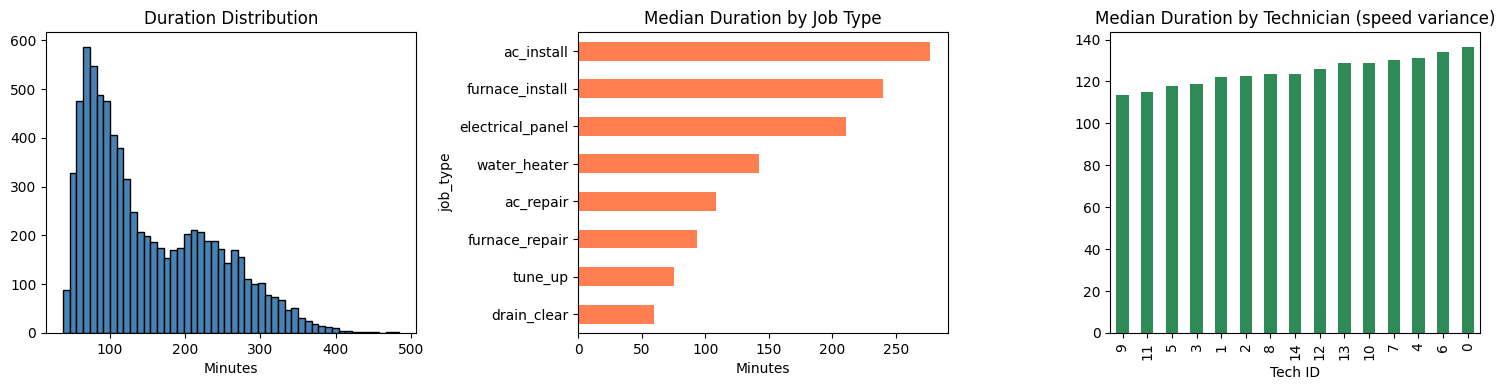

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Overall distribution
axes[0].hist(jobs_df['actual_duration_min'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Duration Distribution'); axes[0].set_xlabel('Minutes')

# By job type (median)
jobs_df.groupby('job_type')['actual_duration_min'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Median Duration by Job Type'); axes[1].set_xlabel('Minutes')

# Technician variance — some techs are consistently faster
tech_medians = jobs_df.groupby('tech_id')['actual_duration_min'].median().sort_values()
tech_medians.plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Median Duration by Technician (speed variance)')
axes[2].set_xlabel('Tech ID')

plt.tight_layout()
plt.savefig('dispatch_eda.png', dpi=100, bbox_inches='tight')
plt.show()


In [4]:
# ─── Model Training ───────────────────────────────────────────────────────────
features = ['job_type', 'equipment_age_yrs', 'property_sqft',
            'new_customer', 'tech_id', 'time_of_day', 'day_of_week']
target = 'actual_duration_min'

X = jobs_df[features]
y = jobs_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing: one-hot encode categoricals, pass numerics through
categorical_features = ['job_type', 'time_of_day', 'day_of_week']
numeric_features = ['equipment_age_yrs', 'property_sqft', 'new_customer', 'tech_id']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

# Gradient Boosted Trees — best for tabular regression with mixed types
gbm = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                         learning_rate=0.05, random_state=42))
])
gbm.fit(X_train, y_train)
gbm_preds = gbm.predict(X_test)

mae  = mean_absolute_error(y_test, gbm_preds)
rmse = np.sqrt(mean_squared_error(y_test, gbm_preds))
print(f"GBM  MAE: {mae:.1f} min  |  RMSE: {rmse:.1f} min")
print(f"Mean actual duration: {y_test.mean():.1f} min")
print(f"MAE as % of mean: {mae/y_test.mean()*100:.1f}%")


GBM  MAE: 6.0 min  |  RMSE: 9.2 min
Mean actual duration: 155.1 min
MAE as % of mean: 3.9%


## Quantile Regression: Building Uncertainty into the Schedule
The **optimizer needs a conservative (P90) estimate**, not just the mean.
If we always schedule based on the mean, ~50% of jobs will run over — cascading
delays all afternoon.

We train quantile regressors for P10, P50, and P90 of the duration distribution.


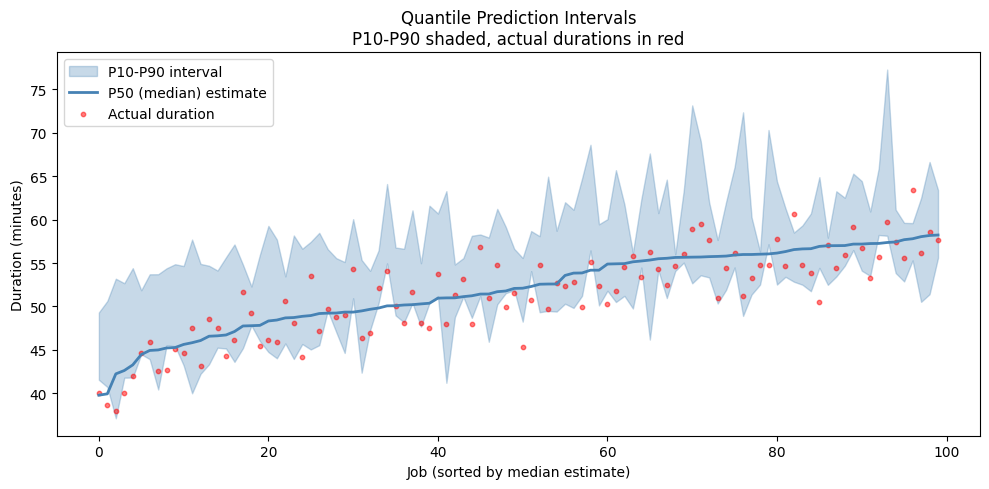

P10-P90 interval coverage: 78.6%  (target: ~80%)


In [5]:
from sklearn.ensemble import GradientBoostingRegressor

def train_quantile(q, X_tr, y_tr, preprocessor):
    """Train a quantile GBM for a given quantile q (0-1)."""
    Xp = preprocessor.transform(X_tr)
    m = GradientBoostingRegressor(loss='quantile', alpha=q,
                                   n_estimators=100, max_depth=4,
                                   learning_rate=0.08, random_state=42)
    m.fit(Xp, y_tr)
    return m

# Fit preprocessor on training data
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

model_p10 = train_quantile(0.10, X_train, y_train, preprocessor)
model_p50 = train_quantile(0.50, X_train, y_train, preprocessor)
model_p90 = train_quantile(0.90, X_train, y_train, preprocessor)

preds_p10 = model_p10.predict(X_test_t)
preds_p50 = model_p50.predict(X_test_t)
preds_p90 = model_p90.predict(X_test_t)

# ─── Visualize prediction intervals ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
idx = np.argsort(preds_p50)[:100]  # sort by median for clean display
ax.fill_between(range(100), preds_p10[idx], preds_p90[idx],
                alpha=0.3, label='P10-P90 interval', color='steelblue')
ax.plot(preds_p50[idx], label='P50 (median) estimate', color='steelblue', lw=2)
ax.scatter(range(100), y_test.values[idx], s=10, alpha=0.5,
           color='red', label='Actual duration')
ax.set_title('Quantile Prediction Intervals\nP10-P90 shaded, actual durations in red')
ax.set_xlabel('Job (sorted by median estimate)')
ax.set_ylabel('Duration (minutes)')
ax.legend()
plt.tight_layout()
plt.savefig('dispatch_quantile.png', dpi=100, bbox_inches='tight')
plt.show()

# Coverage check: actual should fall within P10-P90 about 80% of the time
coverage = ((y_test.values >= preds_p10) & (y_test.values <= preds_p90)).mean()
print(f"P10-P90 interval coverage: {coverage:.1%}  (target: ~80%)")


## Greedy Dispatch Simulation
To show how the duration model feeds the optimizer, we simulate a simple greedy
dispatch: assign each incoming job to the technician who can complete it earliest.


In [6]:
from collections import defaultdict

def simulate_dispatch(n_jobs=30, n_techs=5):
    """
    Greedy dispatch: assign job to tech with earliest available time.
    Uses P90 duration estimates to build in schedule buffer.
    Returns per-tech schedule and utilization.
    """
    rng = np.random.default_rng(99)

    # Generate jobs for one day
    job_types_today = rng.choice(job_types, size=n_jobs)
    new_cust        = rng.binomial(1, 0.35, size=n_jobs)
    eq_age          = rng.uniform(1, 20, size=n_jobs)
    sqft            = rng.normal(1800, 500, size=n_jobs).clip(600, 5000)
    # All jobs are this morning → time_of_day = morning
    job_df_today = pd.DataFrame({
        'job_type': job_types_today,
        'equipment_age_yrs': eq_age.round(1),
        'property_sqft': sqft.round(0),
        'new_customer': new_cust,
        'tech_id': 0,  # placeholder; will vary below
        'time_of_day': 'morning',
        'day_of_week': 'Mon'
    })

    # Tech state: when each tech becomes free (minutes since 8am)
    tech_free_at = [0.0] * n_techs
    schedule = defaultdict(list)

    for i in range(n_jobs):
        # Estimate duration for this job with each tech (use their ID)
        best_tech = None
        best_start = float('inf')

        for t in range(n_techs):
            job_df_today.at[i, 'tech_id'] = t
            sample = job_df_today.iloc[[i]]
            sample_t = preprocessor.transform(sample)
            p90_duration = model_p90.predict(sample_t)[0]
            p50_duration = model_p50.predict(sample_t)[0]

            start_time = tech_free_at[t]
            # Travel time: simple proxy (5-25 min random for this demo)
            travel_time = rng.uniform(5, 25)
            finish_time = start_time + travel_time + p90_duration

            if start_time < best_start:
                best_start   = start_time
                best_tech    = t
                best_p90     = p90_duration
                best_p50     = p50_duration
                best_travel  = travel_time

        tech_free_at[best_tech] = best_start + best_travel + best_p90
        schedule[best_tech].append({
            'job': i, 'type': job_types_today[i],
            'start': best_start, 'p50_est': best_p50, 'p90_est': best_p90
        })

    # Print utilization
    print("=== End-of-Day Tech Schedule Summary ===")
    for t in range(n_techs):
        end_time = tech_free_at[t]
        hrs = end_time / 60
        n_jobs_assigned = len(schedule[t])
        print(f"Tech {t}: {n_jobs_assigned} jobs | Done at {8 + hrs:.1f}h | "
              f"{'OVERTIME' if hrs > 9 else 'On time'}")

    return schedule

sched = simulate_dispatch(n_jobs=40, n_techs=6)


=== End-of-Day Tech Schedule Summary ===
Tech 0: 7 jobs | Done at 22.2h | OVERTIME
Tech 1: 8 jobs | Done at 24.1h | OVERTIME
Tech 2: 8 jobs | Done at 24.9h | OVERTIME
Tech 3: 6 jobs | Done at 23.3h | OVERTIME
Tech 4: 4 jobs | Done at 24.5h | OVERTIME
Tech 5: 7 jobs | Done at 25.0h | OVERTIME


## Key Takeaways for Interview

1. **ML's role is providing accurate inputs to the optimizer** — not doing the optimization itself
2. **Use P90 duration estimates** for scheduling; P50 means half your afternoon will cascade
3. **Technician ID is a valid feature** — some are genuinely faster; this isn't bias, it's personalization
4. **For real-time re-dispatch**: use insertion heuristics (where cheapest to insert new job?)
5. **Full re-optimization** (OR-Tools VRPTW) runs overnight for next-day planning
6. **The feedback loop**: actual duration vs. estimate updates the model on every completed job
